In [240]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)



In [241]:
df = pd.read_csv('data/ecommerce_customer_behavior.csv')



In [242]:
print("Rows and Columns:")
df.shape

print("\n")

print("Column Names:")
df.columns

Rows and Columns:


Column Names:


Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [243]:
df.shape

(350, 11)

In [244]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


## Data Cleaning

This section focuses on identifying and handling missing values, duplicate records, and ensuring the dataset is suitable for further analysis and modeling.

In [247]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [248]:
print("Duplicate Rows:") 
df.duplicated().sum()

Duplicate Rows:


0

In [249]:
df['Satisfaction Level'] = df['Satisfaction Level'].fillna(
    df['Satisfaction Level'].mode()[0]
)


In [250]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
dtype: int64

## Target Variable Creation

A customer is considered churned if they have not made a purchase within the last 30 days.

In [252]:
df['Churn'] = np.where(
    df['Days Since Last Purchase'] > 30,
    1,
    0
)


In [253]:
df['Churn'].value_counts()

Churn
0    226
1    124
Name: count, dtype: int64

In [254]:
df[['Days Since Last Purchase', 'Churn']].head(10)

,Days Since Last Purchase,Churn
0,25,0
1,18,0
2,42,1
3,12,0
4,55,1
5,22,0
6,28,0
7,14,0
8,40,1
9,9,0


In [255]:
df.to_csv(
    'cleaned_ecommerce_data.csv',
    index=False
)


## Data Cleaning

This section focuses on identifying and handling missing values, duplicate records, and preparing the dataset for analysis and machine learning.

In [257]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
Churn                       0
dtype: int64

In [258]:
print("Duplicate Rows:")
df.duplicated().sum()

Duplicate Rows:


0

In [259]:
df['Satisfaction Level'] = df['Satisfaction Level'].fillna(
    df['Satisfaction Level'].mode()[0]
)


In [260]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          0
Churn                       0
dtype: int64

## Target Variable Creation

A customer is considered churned if they have not made a purchase within the last 30 days.

In [262]:
df['Churn'] = np.where(
    df['Days Since Last Purchase'] > 30,
    1,
    0
)

print("Churn variable created successfully")

Churn variable created successfully


In [263]:
df['Churn'].value_counts()

Churn
0    226
1    124
Name: count, dtype: int64

In [264]:
df[['Days Since Last Purchase', 'Churn']].head(10)

,Days Since Last Purchase,Churn
0,25,0
1,18,0
2,42,1
3,12,0
4,55,1
5,22,0
6,28,0
7,14,0
8,40,1
9,9,0


## Exploratory Data Analysis (EDA)

This section explores customer demographics, spending patterns, membership behavior, and churn characteristics to identify meaningful business insights.

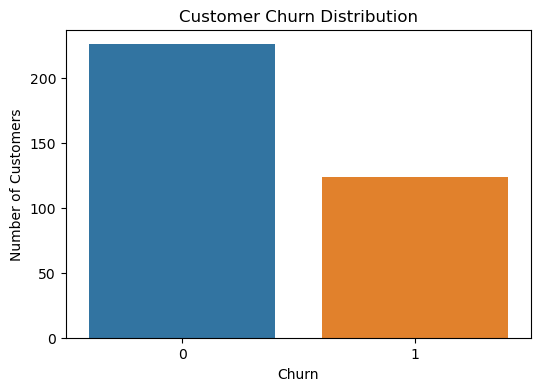

In [266]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.savefig('visuals/churn_distribution.png')
plt.show()

### Insight

The majority of customers remain active, while a significant proportion have churned. This suggests customer retention is an important business challenge and highlights the need for predictive analytics to identify at-risk customers.

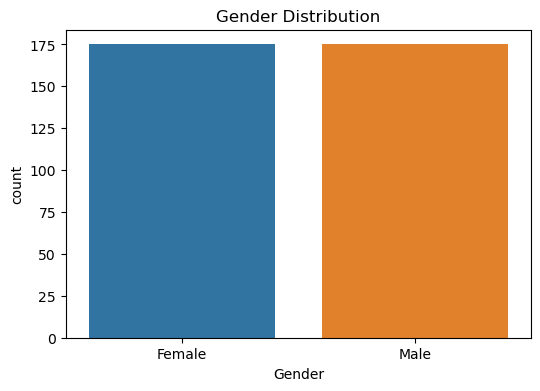

In [268]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    data=df
)

plt.title('Gender Distribution')
plt.show()

### Insight

The customer base contains both male and female customers, providing opportunities to analyze purchasing behavior across demographic groups.

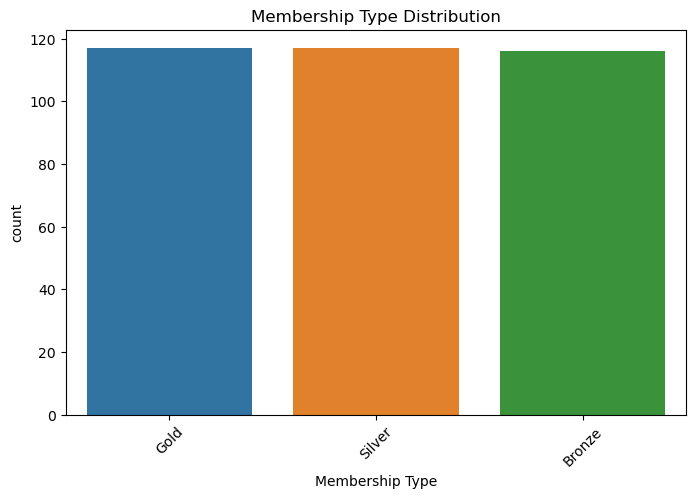

In [270]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Membership Type',
    data=df
)

plt.title('Membership Type Distribution')

plt.xticks(rotation=45)
plt.savefig('visuals/churn_distribution.png')
plt.show()

### Insight

Membership programs play an important role in customer engagement. Understanding how membership levels relate to spending and churn can help improve retention strategies.

C:\Users\hi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


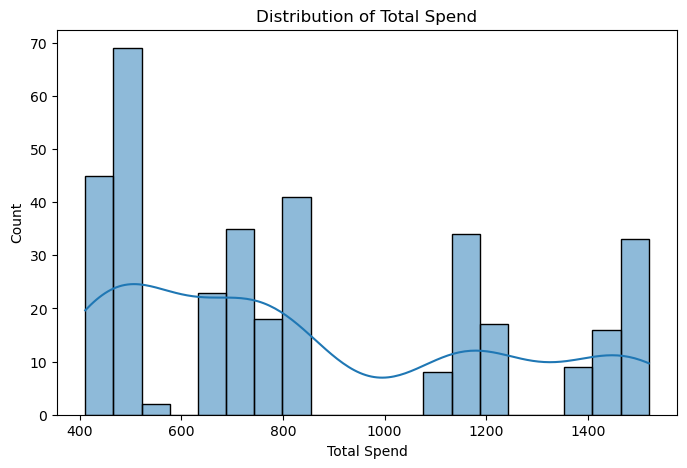

In [272]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Total Spend'],
    bins=20,
    kde=True
)

plt.title('Distribution of Total Spend')

plt.show()

### Insight

Customer spending varies considerably across the customer base. Identifying high-value customers can help prioritize retention efforts and targeted marketing campaigns.

In [275]:
df['Churn_Label'] = df['Churn'].map({
    0: 'Active',
    1: 'Churned'
})

df[['Churn', 'Churn_Label']].head()

,Churn,Churn_Label
0,0,Active
1,0,Active
2,1,Churned
3,0,Active
4,1,Churned


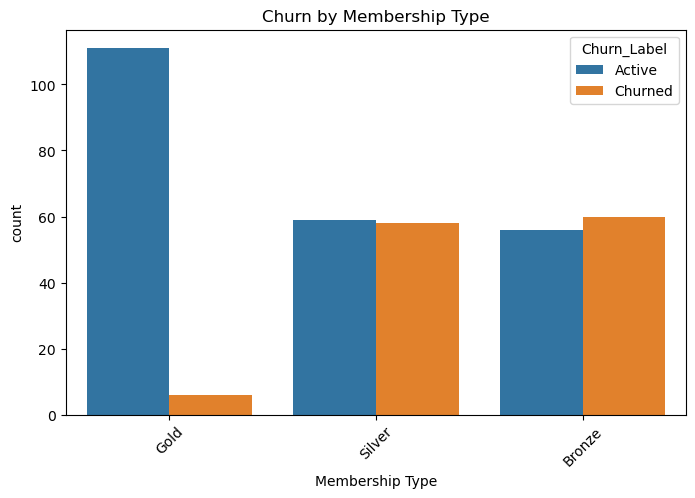

In [279]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Membership Type',
    hue='Churn_Label',
    data=df
)

plt.title('Churn by Membership Type')

plt.xticks(rotation=45)

plt.show()

### Insight

Membership type appears to influence customer retention. Higher membership tiers may demonstrate stronger loyalty and lower churn rates compared to lower-tier memberships.

In [283]:
df['Churn_Label'] = df['Churn'].map({
    0: 'Active',
    1: 'Churned'
})

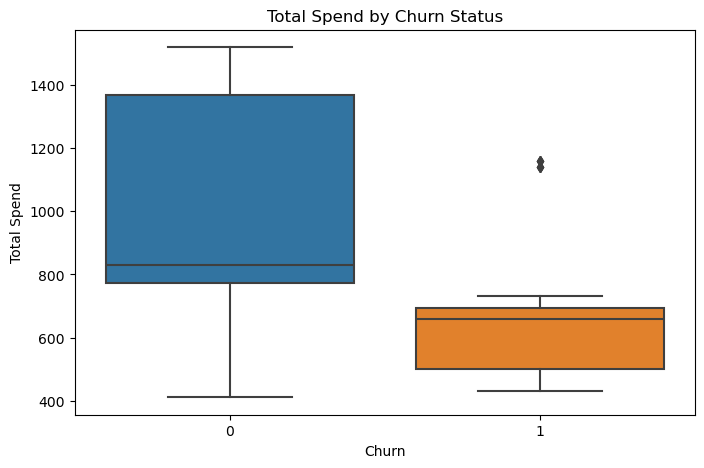

In [285]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Total Spend',
    data=df
)

plt.title('Total Spend by Churn Status')

plt.show()

### Insight

Comparing spending behavior between active and churned customers helps identify whether higher-value customers are more likely to remain engaged with the platform.

In [287]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase,Churn
0,101,29,1120.20,14,4.6,25,0
1,102,34,780.50,11,4.1,18,0
2,103,43,510.75,9,3.4,42,1
3,104,30,1480.30,19,4.7,12,0
4,105,27,720.40,13,4.0,55,1


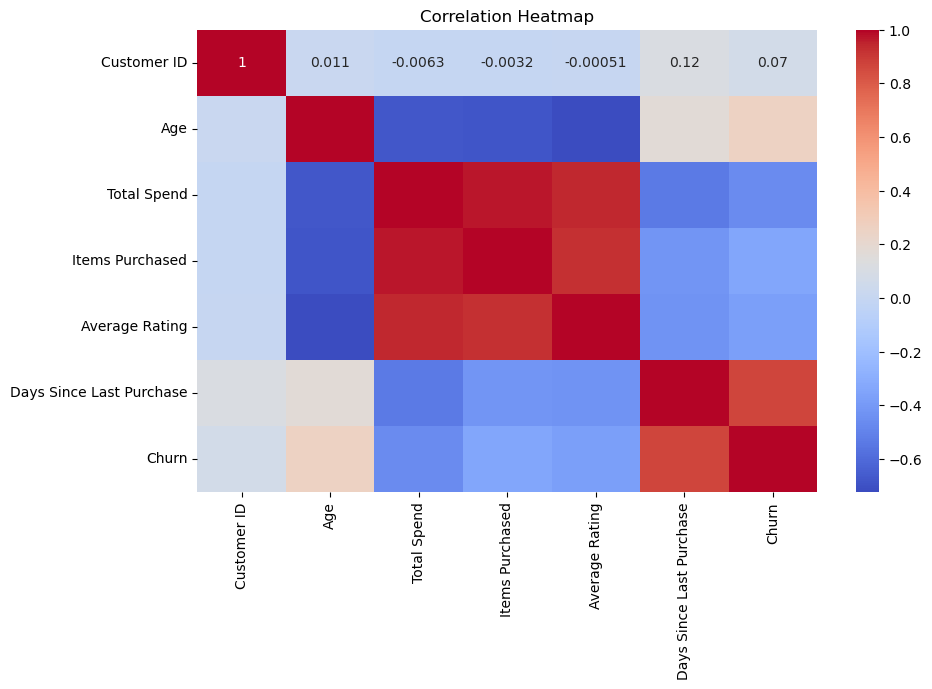

In [289]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.savefig('visuals/churn_distribution.png')
plt.show()

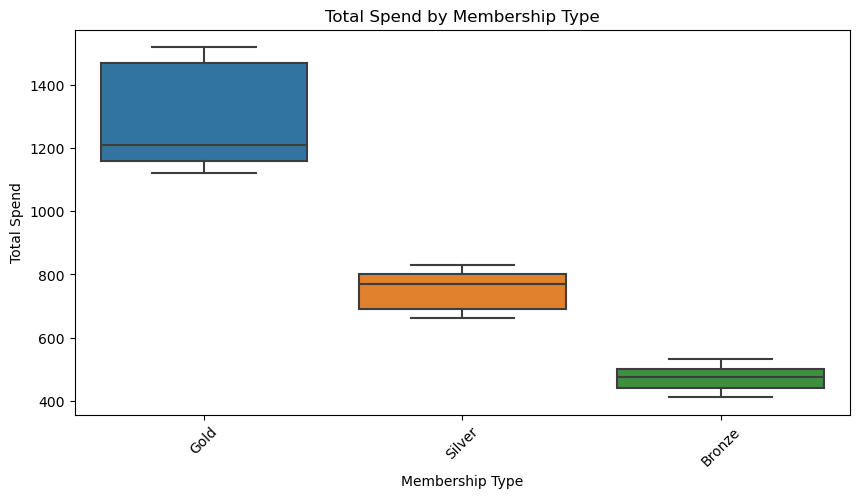

In [291]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Membership Type',
    y='Total Spend',
    data=df
)

plt.title('Total Spend by Membership Type')

plt.xticks(rotation=45)

plt.show()

### Insight

Customer spending varies across membership tiers. Understanding which membership categories contribute the highest revenue can help businesses prioritize customer retention and loyalty strategies.

C:\Users\hi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


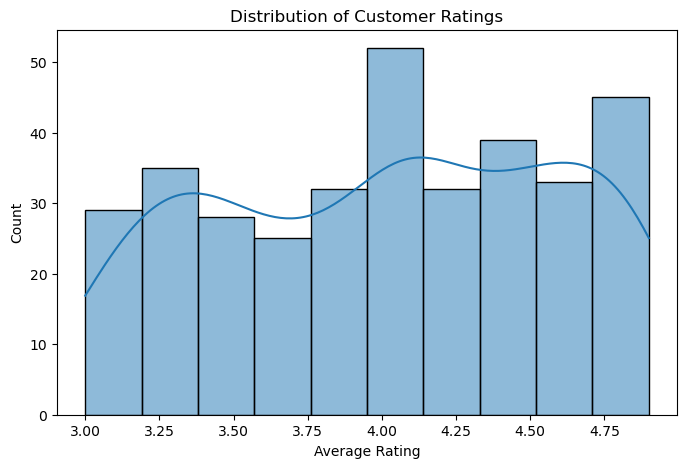

In [294]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Average Rating'],
    bins=10,
    kde=True
)

plt.title('Distribution of Customer Ratings')

plt.show()

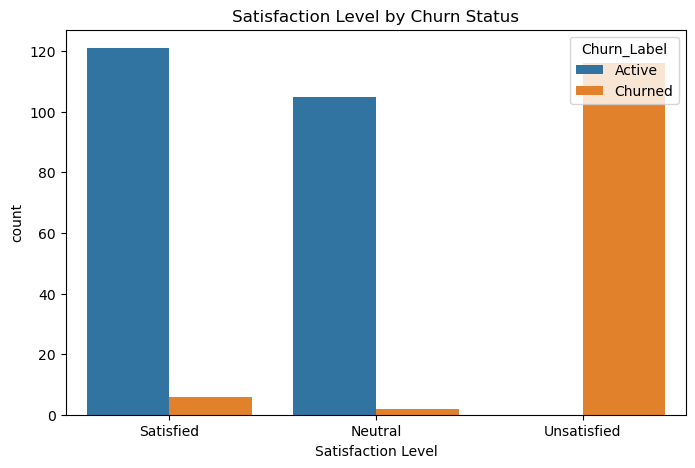

In [296]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Satisfaction Level',
    hue='Churn_Label',
    data=df
)

plt.title('Satisfaction Level by Churn Status')

plt.show()

In [298]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.columns

Index(['Customer ID', 'Age', 'Total Spend', 'Items Purchased',
       'Average Rating', 'Days Since Last Purchase', 'Churn'],
      dtype='object')

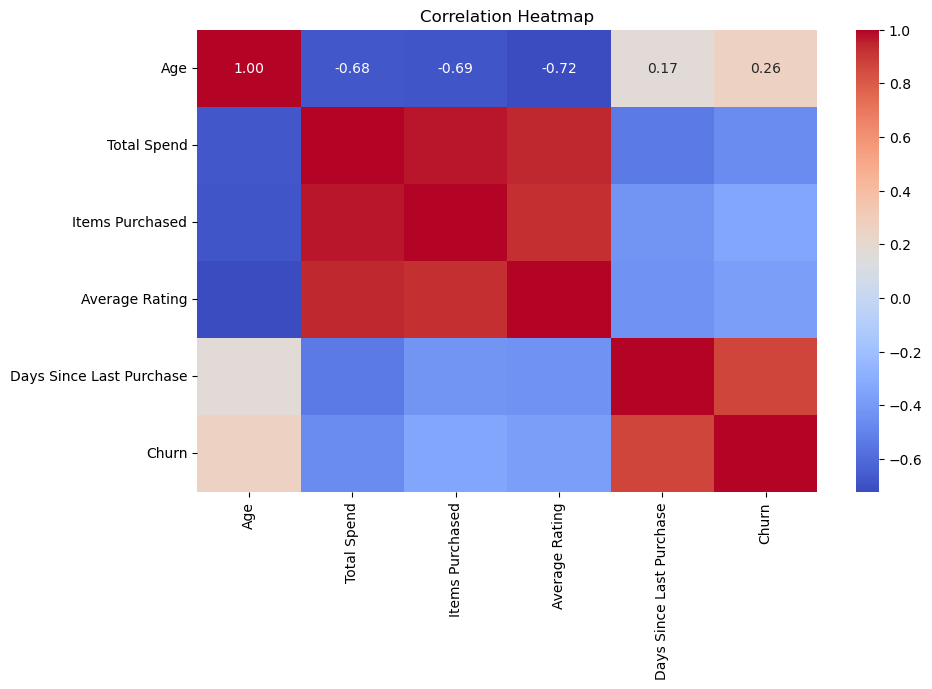

In [300]:
heatmap_df = numeric_df.drop('Customer ID', axis=1)

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

## Feature Engineering

This section creates new features that better capture customer value, engagement, and purchasing behavior.

In [303]:
df['Customer_Lifetime_Value'] = (
    df['Total Spend'] *
    df['Items Purchased']
)

df[['Total Spend',
    'Items Purchased',
    'Customer_Lifetime_Value']].head()

,Total Spend,Items Purchased,Customer_Lifetime_Value
0,1120.20,14,15682.80
1,780.50,11,8585.50
2,510.75,9,4596.75
3,1480.30,19,28125.70
4,720.40,13,9365.20


In [305]:
df['Engagement_Score'] = (
    df['Average Rating'] *
    df['Items Purchased']
)

df[['Average Rating',
    'Items Purchased',
    'Engagement_Score']].head()

,Average Rating,Items Purchased,Engagement_Score
0,4.6,14,64.4
1,4.1,11,45.1
2,3.4,9,30.6
3,4.7,19,89.3
4,4.0,13,52.0


In [307]:
median_spend = df['Total Spend'].median()

df['High_Value_Customer'] = np.where(
    df['Total Spend'] > median_spend,
    1,
    0
)

df['High_Value_Customer'].value_counts()

High_Value_Customer
1    175
0    175
Name: count, dtype: int64

In [309]:
df['Spending_Category'] = pd.qcut(
    df['Total Spend'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

df['Spending_Category'].value_counts()

Spending_Category
Low       124
High      117
Medium    109
Name: count, dtype: int64

In [311]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Churn,Churn_Label,Customer_Lifetime_Value,Engagement_Score,High_Value_Customer,Spending_Category
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,0,Active,15682.80,64.4,1,High
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral,0,Active,8585.50,45.1,1,Medium
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,1,Churned,4596.75,30.6,0,Low
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied,0,Active,28125.70,89.3,1,High
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,1,Churned,9365.20,52.0,0,Medium


## Data Preprocessing

This section prepares the dataset for machine learning by encoding categorical variables, selecting features, and splitting the data into training and testing sets.

In [315]:
model_df = df.copy()

In [317]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = [
    'Gender',
    'City',
    'Membership Type',
    'Discount Applied',
    'Satisfaction Level',
    'Spending_Category'
]

for col in categorical_columns:
    model_df[col] = le.fit_transform(model_df[col])

print("Categorical variables encoded successfully")

Categorical variables encoded successfully


In [319]:
features = [
    'Gender',
    'Age',
    'City',
    'Membership Type',
    'Total Spend',
    'Items Purchased',
    'Average Rating',
    'Discount Applied',
    'Days Since Last Purchase',
    'Satisfaction Level',
    'Customer_Lifetime_Value',
    'Engagement_Score',
    'High_Value_Customer',
    'Spending_Category'
]

X = model_df[features]

y = model_df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (350, 14)
Target shape: (350,)


In [321]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (280, 14)
Testing set: (70, 14)


## Random Forest Model Training

A Random Forest Classifier is used to predict customer churn based on customer demographics, spending behavior, engagement metrics, and engineered features.

In [324]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [326]:
y_pred = rf_model.predict(X_test)

In [328]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

Accuracy: 1.0


In [330]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        25

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



In [332]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[45,  0],
       [ 0, 25]], dtype=int64)

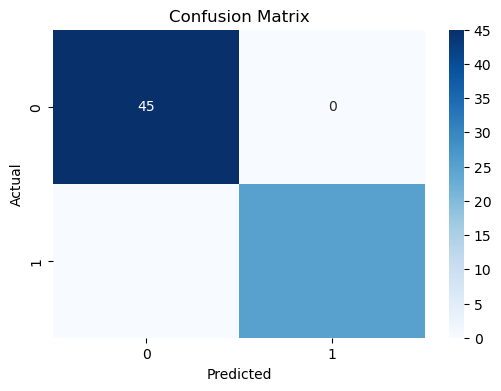

In [334]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [336]:
features_no_leakage = [
    'Gender',
    'Age',
    'City',
    'Membership Type',
    'Total Spend',
    'Items Purchased',
    'Average Rating',
    'Discount Applied',
    'Satisfaction Level',
    'Customer_Lifetime_Value',
    'Engagement_Score',
    'High_Value_Customer',
    'Spending_Category'
]

X2 = model_df[features_no_leakage]

y = model_df['Churn']

In [338]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [340]:
rf_model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model2.fit(X_train2, y_train2)

y_pred2 = rf_model2.predict(X_test2)

In [342]:
accuracy2 = accuracy_score(y_test2, y_pred2)

print("Leakage-Free Accuracy:", accuracy2)

Leakage-Free Accuracy: 0.9857142857142858


In [344]:
print(classification_report(y_test2, y_pred2))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       1.00      0.96      0.98        25

    accuracy                           0.99        70
   macro avg       0.99      0.98      0.98        70
weighted avg       0.99      0.99      0.99        70



In [346]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,Days Since Last Purchase,0.305461
9,Satisfaction Level,0.255134
7,Discount Applied,0.094294
12,High_Value_Customer,0.080079
4,Total Spend,0.065958
1,Age,0.050665
10,Customer_Lifetime_Value,0.047324
11,Engagement_Score,0.033535
6,Average Rating,0.024076
5,Items Purchased,0.023520


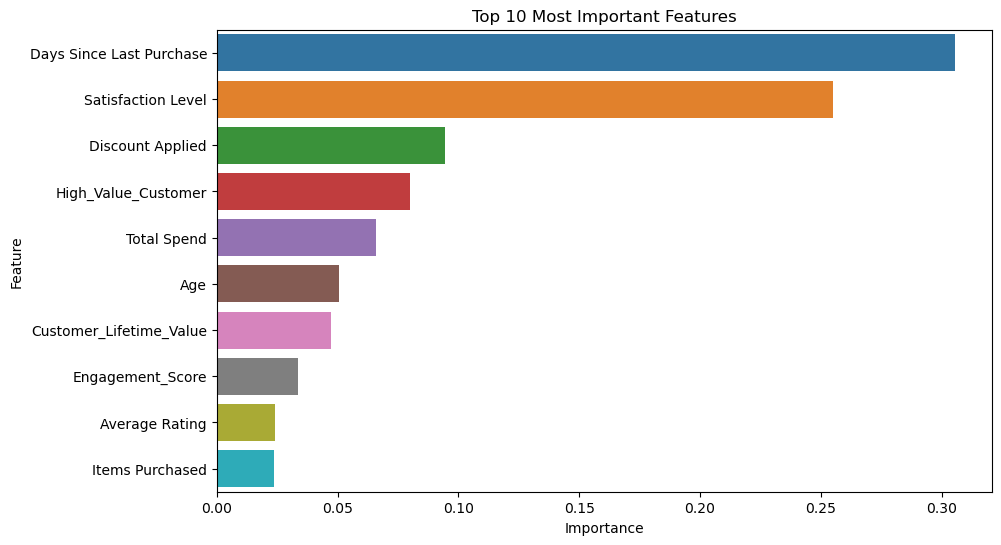

In [348]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Most Important Features')

plt.show()